# Bearing Health: LGB + CAT + XGB Stacking

- 一层模型：`LightGBM` + `CatBoost` + `XGBoost`
- 二层融合：`LightGBM`
- 二层输入：`一层OOF概率 + 全部原始特征 + 工程特征`
- 验证方式：`GroupKFold(case_id)`（防止 case 泄漏）
- 输出：`working/submission.csv`（若不存在则写当前目录）


In [1]:
# 如果平台环境缺包，这个cell会自动安装（可保留）
import sys, subprocess, importlib

def ensure_pkg(import_name, pip_name=None):
    pip_name = pip_name or import_name
    try:
        importlib.import_module(import_name)
    except Exception:
        print(f'Installing {pip_name} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name])

for m, p in [
    ('lightgbm', 'lightgbm'),
    ('xgboost', 'xgboost'),
    ('catboost', 'catboost'),
    ('seaborn', 'seaborn'),
]:
    ensure_pkg(m, p)

print('Dependency check done.')


Dependency check done.


In [2]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import lightgbm as lgb
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
N_CLASSES = 4


In [3]:
# 路径自动识别（平台优先，兼容本地）
from pathlib import Path


def find_data_dir() -> Path:
    candidates = [
        Path('./dataset/public'),
        Path('/root/setup/solution/dataset/public'),
        Path('/kaggle/input/public'),
        Path('/kaggle/working/dataset/public'),
        Path('./public'),
        Path('.'),
    ]
    for p in candidates:
        if (p / 'train.csv').exists() and (p / 'test.csv').exists() and (p / 'signals').exists():
            return p.resolve()

    search_roots = [Path('.'), Path('/root/setup/solution')]
    seen = set()
    for root in search_roots:
        if not root.exists():
            continue
        for train_file in root.rglob('train.csv'):
            parent = train_file.parent
            key = str(parent.resolve())
            if key in seen:
                continue
            seen.add(key)
            if (parent / 'test.csv').exists() and (parent / 'signals').exists():
                return parent.resolve()

    raise FileNotFoundError('Cannot find dataset folder containing train.csv, test.csv, and signals/.')


def find_output_dir() -> Path:
    candidates = [
        Path('./working'),
        Path('/root/setup/solution/working'),
        Path('/kaggle/working'),
        Path('.'),
    ]
    for p in candidates:
        try:
            p.mkdir(parents=True, exist_ok=True)
            probe = p / '.write_test'
            probe.write_text('ok', encoding='utf-8')
            probe.unlink(missing_ok=True)
            return p.resolve()
        except Exception:
            continue
    raise PermissionError('No writable output directory found.')


DATA_DIR = find_data_dir()
OUTPUT_DIR = find_output_dir()

TRAIN_PATH = DATA_DIR / 'train.csv'
TEST_PATH = DATA_DIR / 'test.csv'
SIGNALS_DIR = DATA_DIR / 'signals'
SAMPLE_SUB_PATH = DATA_DIR / 'sample_submission.csv'

print('DATA_DIR  :', DATA_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)
print('train exists :', TRAIN_PATH.exists())
print('test exists  :', TEST_PATH.exists())
print('signals exists:', SIGNALS_DIR.exists())


DATA_DIR  : /Users/songling/Desktop/public
OUTPUT_DIR: /Users/songling/Desktop/public/working
train exists : True
test exists  : True
signals exists: True


In [4]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print('train:', train_df.shape)
print('test :', test_df.shape)
print('target dist:')
print(train_df['Bearing_health_state'].value_counts().sort_index())
print('train cases:', train_df['case_id'].nunique(), 'test cases:', test_df['case_id'].nunique())
print('case overlap:', len(set(train_df['case_id']) & set(test_df['case_id'])))


train: (4878, 41)
test : (1568, 40)
target dist:
Bearing_health_state
0    4212
1     328
2      23
3     315
Name: count, dtype: int64
train cases: 7 test cases: 4
case overlap: 0


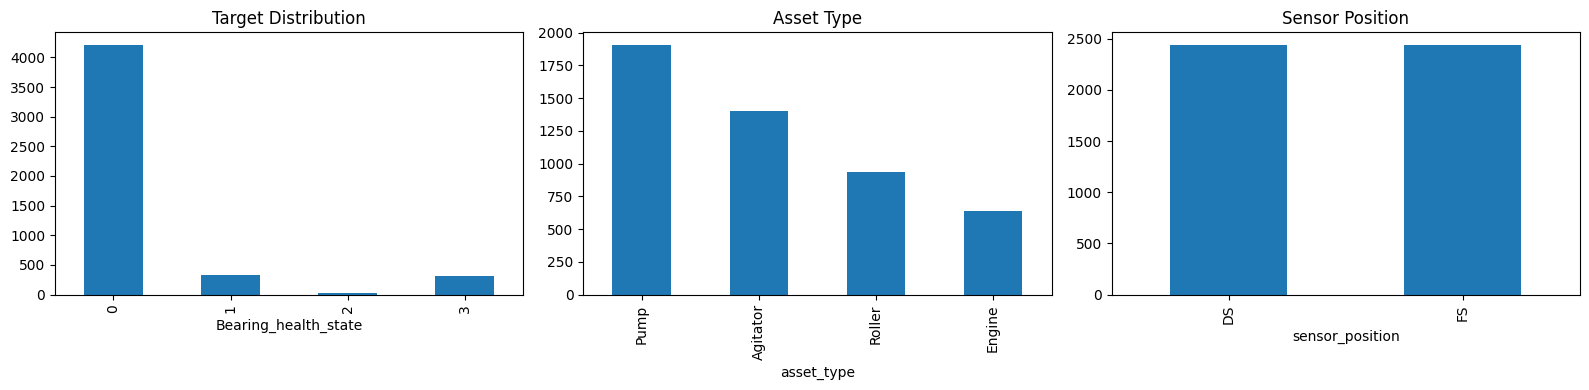

In [5]:
# 轻量EDA
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

train_df['Bearing_health_state'].value_counts().sort_index().plot(kind='bar', ax=axes[0], title='Target Distribution')
train_df['asset_type'].value_counts().plot(kind='bar', ax=axes[1], title='Asset Type')
train_df['sensor_position'].value_counts().plot(kind='bar', ax=axes[2], title='Sensor Position')

plt.tight_layout()
plt.show()


In [6]:
# 特征工程
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    eps = 1e-9

    out['rot_hz'] = out['rpm'] / 60.0
    out['nyquist_hz'] = out['sampling_rate'] / 2.0

    out['ftf_hz'] = out['ftf_multiple'] * out['rot_hz']
    out['bpf_hz'] = out['bpf_multiple'] * out['rot_hz']
    out['bpfo_hz'] = out['bpfo_multiple'] * out['rot_hz']
    out['bpfi_hz'] = out['bpfi_multiple'] * out['rot_hz']

    out['ftf_norm'] = out['ftf_hz'] / (out['nyquist_hz'] + eps)
    out['bpf_norm'] = out['bpf_hz'] / (out['nyquist_hz'] + eps)
    out['bpfo_norm'] = out['bpfo_hz'] / (out['nyquist_hz'] + eps)
    out['bpfi_norm'] = out['bpfi_hz'] / (out['nyquist_hz'] + eps)

    out['fft_peak_hz'] = out['fft_peak_freq_norm'] * out['nyquist_hz']

    out['delta_ftf'] = np.abs(out['fft_peak_hz'] - out['ftf_hz'])
    out['delta_bpf'] = np.abs(out['fft_peak_hz'] - out['bpf_hz'])
    out['delta_bpfo'] = np.abs(out['fft_peak_hz'] - out['bpfo_hz'])
    out['delta_bpfi'] = np.abs(out['fft_peak_hz'] - out['bpfi_hz'])
    out['min_fault_delta'] = out[['delta_ftf', 'delta_bpf', 'delta_bpfo', 'delta_bpfi']].min(axis=1)

    out['band_energy_sum'] = (
        out['band_energy_low'] + out['band_energy_mid_low'] + out['band_energy_mid_high'] + out['band_energy_high']
    )
    out['band_low_ratio'] = out['band_energy_low'] / (np.abs(out['band_energy_sum']) + eps)
    out['band_mid_low_ratio'] = out['band_energy_mid_low'] / (np.abs(out['band_energy_sum']) + eps)
    out['band_mid_high_ratio'] = out['band_energy_mid_high'] / (np.abs(out['band_energy_sum']) + eps)
    out['band_high_ratio'] = out['band_energy_high'] / (np.abs(out['band_energy_sum']) + eps)

    out['rpm_is_zero'] = (out['rpm'] == 0).astype(int)
    out['signal_seconds'] = out['signal_length'] / (out['sampling_rate'] + eps)

    out['peak_rms_ratio2'] = out['peak'] / (out['rms'] + eps)
    out['std_rms_ratio'] = out['std'] / (out['rms'] + eps)

    return out


In [7]:
# 拼接后统一做特征工程，保证train/test列一致
full_df = pd.concat([train_df.drop(columns=['Bearing_health_state']), test_df], axis=0, ignore_index=True)
full_df = add_features(full_df)

cat_cols = ['sensor_position', 'asset_type', 'bearing_model', 'fault_origin', 'unit']
for c in cat_cols:
    full_df[c] = full_df[c].astype(str).fillna('NA')

n_train = len(train_df)
y = train_df['Bearing_health_state'].astype(int).values
groups = train_df['case_id'].values

# 保留“全部原始特征+工程特征”，仅去掉ID类
feature_cols = [c for c in full_df.columns if c not in ['measurement_id', 'case_id']]

# 给 CAT 用（保留字符串类别）
X_all_raw = full_df[feature_cols].copy()
X_train_raw = X_all_raw.iloc[:n_train].reset_index(drop=True)
X_test_raw = X_all_raw.iloc[n_train:].reset_index(drop=True)

# 给 LGB 用（类别数值编码）
X_all_lgb = X_all_raw.copy()
for ccol in cat_cols:
    if ccol in X_all_lgb.columns:
        X_all_lgb[ccol] = X_all_lgb[ccol].astype('category').cat.codes.astype('int32')
X_train_lgb = X_all_lgb.iloc[:n_train].reset_index(drop=True)
X_test_lgb = X_all_lgb.iloc[n_train:].reset_index(drop=True)

# 给 XGB/二层融合 用（全量one-hot，包含全部原始+工程特征）
X_all_num = pd.get_dummies(X_all_raw, columns=cat_cols, dummy_na=True)
X_train_num = X_all_num.iloc[:n_train].reset_index(drop=True)
X_test_num = X_all_num.iloc[n_train:].reset_index(drop=True)

print('raw feature count :', len(feature_cols))
print('lgb feature count :', X_train_lgb.shape[1])
print('numeric feature count (onehot):', X_train_num.shape[1])


raw feature count : 63
lgb feature count : 63
numeric feature count (onehot): 87


In [8]:
def map_proba_to_global(proba_local, classes_global, n_classes=4):
    out = np.zeros((proba_local.shape[0], n_classes), dtype=float)
    out[:, classes_global.astype(int)] = proba_local
    return out


def fit_predict_lgb(X_tr, y_tr_enc, X_pred, n_class_local, random_state=42):
    if n_class_local <= 1:
        p = np.ones((len(X_pred), 1), dtype=float)
        return p

    if n_class_local == 2:
        model = lgb.LGBMClassifier(
            objective='binary',
            learning_rate=0.03,
            n_estimators=700,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.85,
            reg_alpha=0.1,
            reg_lambda=0.1,
            random_state=random_state,
            verbosity=-1,
        )
    else:
        model = lgb.LGBMClassifier(
            objective='multiclass',
            num_class=n_class_local,
            learning_rate=0.03,
            n_estimators=900,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.85,
            reg_alpha=0.1,
            reg_lambda=0.1,
            random_state=random_state,
            verbosity=-1,
        )

    model.fit(X_tr, y_tr_enc)
    p = model.predict_proba(X_pred)
    if n_class_local == 2 and p.ndim == 1:
        p = np.vstack([1-p, p]).T
    return p


def fit_predict_cat(X_tr, y_tr_enc, X_pred, cat_idx, n_class_local, random_state=42):
    if n_class_local <= 1:
        p = np.ones((len(X_pred), 1), dtype=float)
        return p

    if n_class_local == 2:
        model = CatBoostClassifier(
            loss_function='Logloss',
            eval_metric='AUC',
            learning_rate=0.03,
            depth=6,
            iterations=900,
            random_seed=random_state,
            verbose=False,
            allow_writing_files=False,
        )
    else:
        model = CatBoostClassifier(
            loss_function='MultiClass',
            learning_rate=0.03,
            depth=6,
            iterations=1000,
            random_seed=random_state,
            verbose=False,
            allow_writing_files=False,
        )

    model.fit(X_tr, y_tr_enc, cat_features=cat_idx)
    p = model.predict_proba(X_pred)
    if n_class_local == 2 and p.ndim == 1:
        p = np.vstack([1-p, p]).T
    return p


def fit_predict_xgb(X_tr, y_tr_enc, X_pred, n_class_local, random_state=42):
    if n_class_local <= 1:
        p = np.ones((len(X_pred), 1), dtype=float)
        return p

    if n_class_local == 2:
        model = XGBClassifier(
            objective='binary:logistic',
            n_estimators=900,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=random_state,
            tree_method='hist',
            n_jobs=-1,
            eval_metric='logloss',
        )
    else:
        model = XGBClassifier(
            objective='multi:softprob',
            num_class=n_class_local,
            n_estimators=1000,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=random_state,
            tree_method='hist',
            n_jobs=-1,
            eval_metric='mlogloss',
        )

    model.fit(X_tr, y_tr_enc)
    p = model.predict_proba(X_pred)
    if n_class_local == 2 and p.ndim == 1:
        p = np.vstack([1-p, p]).T
    return p


In [9]:
# 一层：LGB + CAT + XGB，使用 GroupKFold(case_id)
gkf = GroupKFold(n_splits=5)

oof_lgb = np.zeros((n_train, N_CLASSES), dtype=float)
oof_cat = np.zeros((n_train, N_CLASSES), dtype=float)
oof_xgb = np.zeros((n_train, N_CLASSES), dtype=float)

test_lgb = np.zeros((len(test_df), N_CLASSES), dtype=float)
test_cat = np.zeros((len(test_df), N_CLASSES), dtype=float)
test_xgb = np.zeros((len(test_df), N_CLASSES), dtype=float)

cat_idx = [X_train_raw.columns.get_loc(c) for c in cat_cols if c in X_train_raw.columns]

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_train_raw, y, groups), 1):
    Xtr_raw, Xva_raw = X_train_raw.iloc[tr_idx].copy(), X_train_raw.iloc[va_idx].copy()
    Xtr_lgb, Xva_lgb = X_train_lgb.iloc[tr_idx].copy(), X_train_lgb.iloc[va_idx].copy()
    Xtr_num, Xva_num = X_train_num.iloc[tr_idx].copy(), X_train_num.iloc[va_idx].copy()

    y_tr = y[tr_idx]
    y_va = y[va_idx]

    le = LabelEncoder()
    y_tr_enc = le.fit_transform(y_tr)
    classes_global = le.classes_
    n_class_local = len(classes_global)

    # LGB base
    p_lgb_va_local = fit_predict_lgb(Xtr_lgb, y_tr_enc, Xva_lgb, n_class_local, random_state=SEED + fold)
    p_lgb_te_local = fit_predict_lgb(Xtr_lgb, y_tr_enc, X_test_lgb, n_class_local, random_state=SEED + 100 + fold)

    # CAT base
    p_cat_va_local = fit_predict_cat(Xtr_raw, y_tr_enc, Xva_raw, cat_idx, n_class_local, random_state=SEED + 200 + fold)
    p_cat_te_local = fit_predict_cat(Xtr_raw, y_tr_enc, X_test_raw, cat_idx, n_class_local, random_state=SEED + 300 + fold)

    # XGB base
    p_xgb_va_local = fit_predict_xgb(Xtr_num, y_tr_enc, Xva_num, n_class_local, random_state=SEED + 400 + fold)
    p_xgb_te_local = fit_predict_xgb(Xtr_num, y_tr_enc, X_test_num, n_class_local, random_state=SEED + 500 + fold)

    # map local classes -> global 0..3
    p_lgb_va = map_proba_to_global(p_lgb_va_local, classes_global, N_CLASSES)
    p_cat_va = map_proba_to_global(p_cat_va_local, classes_global, N_CLASSES)
    p_xgb_va = map_proba_to_global(p_xgb_va_local, classes_global, N_CLASSES)

    p_lgb_te = map_proba_to_global(p_lgb_te_local, classes_global, N_CLASSES)
    p_cat_te = map_proba_to_global(p_cat_te_local, classes_global, N_CLASSES)
    p_xgb_te = map_proba_to_global(p_xgb_te_local, classes_global, N_CLASSES)

    oof_lgb[va_idx] = p_lgb_va
    oof_cat[va_idx] = p_cat_va
    oof_xgb[va_idx] = p_xgb_va

    test_lgb += p_lgb_te / gkf.n_splits
    test_cat += p_cat_te / gkf.n_splits
    test_xgb += p_xgb_te / gkf.n_splits

    fold_lgb = f1_score(y_va, p_lgb_va.argmax(axis=1), average='macro')
    fold_cat = f1_score(y_va, p_cat_va.argmax(axis=1), average='macro')
    fold_xgb = f1_score(y_va, p_xgb_va.argmax(axis=1), average='macro')
    print(f'Fold {fold}: LGB={fold_lgb:.5f} | CAT={fold_cat:.5f} | XGB={fold_xgb:.5f}')

print()
print('OOF Macro F1')
print('LGB:', f1_score(y, oof_lgb.argmax(axis=1), average='macro'))
print('CAT:', f1_score(y, oof_cat.argmax(axis=1), average='macro'))
print('XGB:', f1_score(y, oof_xgb.argmax(axis=1), average='macro'))


Fold 1: LGB=0.54156 | CAT=0.55830 | XGB=0.54119


Fold 2: LGB=0.49586 | CAT=0.49586 | XGB=0.49586


Fold 3: LGB=0.43156 | CAT=0.43156 | XGB=0.43156


Fold 4: LGB=0.35421 | CAT=0.34810 | XGB=0.33423


Fold 5: LGB=0.21902 | CAT=0.30018 | XGB=0.21895

OOF Macro F1
LGB: 0.2639871331178184
CAT: 0.2964556128728283
XGB: 0.252471371189419


In [10]:
# 二层输入 = 一层OOF概率 + 全部原始/工程特征（one-hot后的全量特征）
meta_train = pd.concat([
    pd.DataFrame(oof_lgb, columns=[f'lgb_p{i}' for i in range(N_CLASSES)]),
    pd.DataFrame(oof_cat, columns=[f'cat_p{i}' for i in range(N_CLASSES)]),
    pd.DataFrame(oof_xgb, columns=[f'xgb_p{i}' for i in range(N_CLASSES)]),
    X_train_num.reset_index(drop=True),
], axis=1)

meta_test = pd.concat([
    pd.DataFrame(test_lgb, columns=[f'lgb_p{i}' for i in range(N_CLASSES)]),
    pd.DataFrame(test_cat, columns=[f'cat_p{i}' for i in range(N_CLASSES)]),
    pd.DataFrame(test_xgb, columns=[f'xgb_p{i}' for i in range(N_CLASSES)]),
    X_test_num.reset_index(drop=True),
], axis=1)

print('meta_train shape:', meta_train.shape)
print('meta_test  shape:', meta_test.shape)


meta_train shape: (4878, 99)
meta_test  shape: (1568, 99)


In [11]:
# 二层模型：LGB（同样按 GroupKFold 做 OOF）
oof_meta = np.zeros((n_train, N_CLASSES), dtype=float)
meta_test_pred = np.zeros((len(test_df), N_CLASSES), dtype=float)

for fold, (tr_idx, va_idx) in enumerate(gkf.split(meta_train, y, groups), 1):
    Xm_tr = meta_train.iloc[tr_idx]
    Xm_va = meta_train.iloc[va_idx]
    ym_tr = y[tr_idx]
    ym_va = y[va_idx]

    le = LabelEncoder()
    ym_tr_enc = le.fit_transform(ym_tr)
    cls_g = le.classes_
    k = len(cls_g)

    if k == 2:
        meta_model = lgb.LGBMClassifier(
            objective='binary',
            learning_rate=0.03,
            n_estimators=900,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_alpha=0.1,
            reg_lambda=0.2,
            random_state=SEED + 700 + fold,
            verbosity=-1,
        )
    else:
        meta_model = lgb.LGBMClassifier(
            objective='multiclass',
            num_class=k,
            learning_rate=0.03,
            n_estimators=1000,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_alpha=0.1,
            reg_lambda=0.2,
            random_state=SEED + 700 + fold,
            verbosity=-1,
        )

    meta_model.fit(Xm_tr, ym_tr_enc)

    p_va_local = meta_model.predict_proba(Xm_va)
    p_te_local = meta_model.predict_proba(meta_test)

    if k == 2 and p_va_local.ndim == 1:
        p_va_local = np.vstack([1-p_va_local, p_va_local]).T
    if k == 2 and p_te_local.ndim == 1:
        p_te_local = np.vstack([1-p_te_local, p_te_local]).T

    p_va = map_proba_to_global(p_va_local, cls_g, N_CLASSES)
    p_te = map_proba_to_global(p_te_local, cls_g, N_CLASSES)

    oof_meta[va_idx] = p_va
    meta_test_pred += p_te / gkf.n_splits

    fold_score = f1_score(ym_va, p_va.argmax(axis=1), average='macro')
    print(f'Meta Fold {fold}: {fold_score:.5f}')

meta_oof_f1 = f1_score(y, oof_meta.argmax(axis=1), average='macro')
print()
print('Meta OOF Macro F1:', meta_oof_f1)


Meta Fold 1: 0.54477


Meta Fold 2: 0.49586


Meta Fold 3: 0.43156


Meta Fold 4: 0.26539


Meta Fold 5: 0.24272

Meta OOF Macro F1: 0.25221253221917045


              precision    recall  f1-score   support

           0     0.8681    0.9031    0.8853      4212
           1     0.0000    0.0000    0.0000       328
           2     0.0000    0.0000    0.0000        23
           3     0.1025    0.1556    0.1236       315

    accuracy                         0.7899      4878
   macro avg     0.2427    0.2647    0.2522      4878
weighted avg     0.7562    0.7899    0.7724      4878



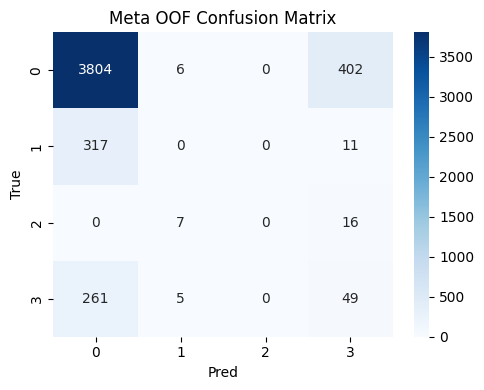

In [12]:
print(classification_report(y, oof_meta.argmax(axis=1), digits=4))

cm = confusion_matrix(y, oof_meta.argmax(axis=1), labels=[0,1,2,3])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.xlabel('Pred')
plt.ylabel('True')
plt.title('Meta OOF Confusion Matrix')
plt.tight_layout()
plt.show()


In [13]:
# 生成提交
final_pred = meta_test_pred.argmax(axis=1).astype(int)

sub = pd.DataFrame({
    'measurement_id': test_df['measurement_id'].astype(int),
    'Bearing_health_state': final_pred
})

sub_path = OUTPUT_DIR / 'submission.csv'
sub.to_csv(sub_path, index=False)

print('Saved:', sub_path.resolve())
print(sub.head())
print('rows:', len(sub), 'unique ids:', sub['measurement_id'].nunique())
print('label dist:')
print(sub['Bearing_health_state'].value_counts().sort_index())


Saved: /Users/songling/Desktop/public/working/submission.csv
   measurement_id  Bearing_health_state
0            4878                     0
1            4879                     0
2            4880                     0
3            4881                     0
4            4882                     0
rows: 1568 unique ids: 1568
label dist:
Bearing_health_state
0    1566
1       2
Name: count, dtype: int64
